# **Projeto de Análise de Dados Climáticos no Brasil**

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python

**Período analisado:** 2015 a 2024

**Base de dados:** `simulacao_clima_brasil.csv`

## **1. Introdução**



Este projeto tem como objetivo analisar dados climáticos do Brasil entre 2015 e 2024, buscando identificar padrões relacionados à temperatura, chuva, eventos extremos e sazonalidade.

A análise compara regiões e estados, investiga a evolução dos indicadores ao longo do tempo e culmina em um dashboard interativo desenvolvido com Streamlit.

## **2. Contextualização climática**



As mudanças climáticas e os eventos extremos afetam diferentes áreas da sociedade:

- **Agricultura:** secas, chuvas intensas e variações de temperatura influenciam a produtividade e o planejamento do plantio.
- **Abastecimento de água:** períodos de seca e de chuva intensa afetam a disponibilidade e a gestão dos recursos hídricos.
- **Energia:** a temperatura e o regime de chuvas influenciam a demanda e a geração de energia.
- **Saúde pública:** ondas de calor, umidade elevada e eventos extremos impactam a saúde da população.
- **Meio ambiente:** mudanças no clima alteram ecossistemas e aumentam riscos ambientais.
- **Qualidade de vida:** alagamentos, calor excessivo e desastres afetam o dia a dia nas cidades.

O monitoramento de indicadores climáticos permite identificar padrões ambientais, períodos críticos e tendências ao longo do tempo. Neste projeto, esse monitoramento é feito sobre uma **base de dados simulada**, o que será considerado na interpretação dos resultados.

## **3. Explicação da base**



A base de dados utilizada neste projeto é composta por registros climáticos simulados do Brasil, abrangendo o período de 2015 a 2024.

Cada registro apresenta informações relacionadas ao período da medição, à localização e às condições climáticas observadas. Entre as principais variáveis estão a temperatura média, temperatura máxima, temperatura mínima, volume de chuva, umidade, velocidade do vento, quantidade de eventos extremos e nível de alerta.

A base permite realizar análises temporais e comparações entre diferentes regiões, estados e cidades brasileiras. Essas características possibilitam investigar a evolução das condições climáticas, identificar períodos com maior ocorrência de eventos extremos e observar diferenças entre localidades.

As variáveis disponíveis na base são:

| Variável | Descrição |
|---|---|
| `ano` | Ano da medição |
| `mes` | Mês da medição |
| `data` | Data de referência |
| `regiao` | Região do Brasil |
| `uf` | Estado |
| `cidade` | Cidade monitorada |
| `temperatura_media` | Temperatura média |
| `temperatura_maxima` | Temperatura máxima |
| `temperatura_minima` | Temperatura mínima |
| `chuva_mm` | Volume de chuva em milímetros |
| `umidade` | Umidade relativa do ar |
| `velocidade_vento` | Velocidade média do vento |
| `eventos_extremos` | Quantidade de eventos extremos |
| `nivel_alerta` | Classificação do nível de alerta |

## **4. Leitura dos dados**

A base de dados foi carregada para o ambiente de análise utilizando a biblioteca Pandas. A leitura inicial permite verificar os registros disponíveis e analisar a estrutura do conjunto de dados utilizado no projeto.

In [37]:
import pandas as pd

df = pd.read_csv("simulacao_clima_brasil.csv")

df.head()

,ano,mes,data,regiao,uf,cidade,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,27.9,34.7,22.5,16.3,42.8,31.5,1,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,24.4,28.1,17.9,96.5,74.9,33.6,2,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,21.1,24.9,17.5,155.3,86.6,3.5,0,Crítico
3,2015,1,2015-01-01,Norte,RO,Porto Velho,25.5,29.7,21.3,137.5,89.3,16.7,1,Baixo
4,2015,1,2015-01-01,Norte,TO,Palmas,23.2,30.2,17.6,202.1,46.4,16.4,2,Médio


## **5. Limpeza e preparação**

A etapa de limpeza e preparação foi realizada para garantir que os dados estivessem adequados para as análises posteriores. Foram verificadas as informações ausentes, os registros duplicados e os tipos das variáveis utilizadas no projeto.

In [38]:
print("Valores ausentes:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nTipos das variáveis:")
print(df.dtypes)

print("\nFormato da coluna data:")
df["data"] = pd.to_datetime(df["data"])
print(df["data"].dtype)

print("\nRegistros com temperaturas inconsistentes:")
temperaturas_inconsistentes = df[
    (df["temperatura_minima"] > df["temperatura_media"]) |
    (df["temperatura_media"] > df["temperatura_maxima"])
]

print(len(temperaturas_inconsistentes))

print("\nDistribuição do nível de alerta:")
print(df["nivel_alerta"].value_counts())

print("\nMaior volume de chuva registrado:")
print(df["chuva_mm"].max())

print("\nMaior temperatura máxima registrada:")
print(df["temperatura_maxima"].max())

print("\nMenor temperatura mínima registrada:")
print(df["temperatura_minima"].min())

Valores ausentes:
ano                   0
mes                   0
data                  0
regiao                0
uf                    0
cidade                0
temperatura_media     0
temperatura_maxima    0
temperatura_minima    0
chuva_mm              0
umidade               0
velocidade_vento      0
eventos_extremos      0
nivel_alerta          0
dtype: int64

Registros duplicados:
0

Tipos das variáveis:
ano                     int64
mes                     int64
data                   object
regiao                 object
uf                     object
cidade                 object
temperatura_media     float64
temperatura_maxima    float64
temperatura_minima    float64
chuva_mm              float64
umidade               float64
velocidade_vento      float64
eventos_extremos        int64
nivel_alerta           object
dtype: object

Formato da coluna data:
datetime64[ns]

Registros com temperaturas inconsistentes:
0

Distribuição do nível de alerta:
nivel_alerta
Baixo      1156
Méd

Após as verificações, os dados foram considerados adequados para as análises realizadas no projeto. Não foram identificados valores ausentes, registros duplicados ou inconsistências na ordem das temperaturas. Dessa forma, não foi necessário remover registros da base.

## **6. Engenharia de atributos**

Nesta etapa, são criadas novas informações a partir das variáveis existentes na base de dados, com o objetivo de facilitar as análises temporais e sazonais dos dados climáticos.

In [39]:
df["data"] = pd.to_datetime(df["data"])

df["ano"] = df["data"].dt.year
df["mes_numero"] = df["data"].dt.month

df["mes_nome"] = df["mes_numero"].map({
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez"
})

df["estacao"] = df["mes_numero"].map({
    12: "Verão",
    1: "Verão",
    2: "Verão",
    3: "Outono",
    4: "Outono",
    5: "Outono",
    6: "Inverno",
    7: "Inverno",
    8: "Inverno",
    9: "Primavera",
    10: "Primavera",
    11: "Primavera"
})

df.head()

,ano,mes,data,regiao,uf,cidade,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos,nivel_alerta,mes_numero,mes_nome,estacao
0,2015,1,2015-01-01,Norte,AM,Manaus,27.9,34.7,22.5,16.3,42.8,31.5,1,Alto,1,Jan,Verão
1,2015,1,2015-01-01,Norte,PA,Belém,24.4,28.1,17.9,96.5,74.9,33.6,2,Médio,1,Jan,Verão
2,2015,1,2015-01-01,Norte,PA,Santarém,21.1,24.9,17.5,155.3,86.6,3.5,0,Crítico,1,Jan,Verão
3,2015,1,2015-01-01,Norte,RO,Porto Velho,25.5,29.7,21.3,137.5,89.3,16.7,1,Baixo,1,Jan,Verão
4,2015,1,2015-01-01,Norte,TO,Palmas,23.2,30.2,17.6,202.1,46.4,16.4,2,Médio,1,Jan,Verão


## **7. KPIs**

Nesta etapa, são calculados os principais indicadores climáticos da base de dados, considerando a temperatura média nacional, o volume total de chuva, a cidade com maior temperatura média, o estado com maior volume de chuva, o total de eventos extremos e a umidade média.

In [40]:
temperatura_media_nacional = df["temperatura_media"].mean()

chuva_total = df["chuva_mm"].sum()

cidade_mais_quente = (
    df.groupby("cidade")["temperatura_media"]
    .mean()
    .idxmax()
)

estado_mais_chuvoso = (
    df.groupby("uf")["chuva_mm"]
    .sum()
    .idxmax()
)

total_eventos_extremos = df["eventos_extremos"].sum()

umidade_media = df["umidade"].mean()

print(f"Temperatura média nacional: {temperatura_media_nacional:.2f} °C")
print(f"Chuva total: {chuva_total:,.2f} mm")
print(f"Cidade com maior temperatura média: {cidade_mais_quente}")
print(f"Estado com maior volume de chuva: {estado_mais_chuvoso}")
print(f"Total de eventos extremos: {total_eventos_extremos:,.0f}")
print(f"Umidade média: {umidade_media:.2f}%")

Temperatura média nacional: 24.99 °C
Chuva total: 470,175.10 mm
Cidade com maior temperatura média: Vila Velha
Estado com maior volume de chuva: RJ
Total de eventos extremos: 8,918
Umidade média: 66.41%


## **8. Visualizações**

Nesta etapa, são apresentados gráficos para analisar os principais padrões dos dados climáticos. As visualizações consideram a evolução da temperatura e da chuva ao longo do tempo, as diferenças entre estados e regiões, a ocorrência de eventos extremos, a sazonalidade e a relação entre temperatura e chuva.

**Temperatura média ao longo do tempo**

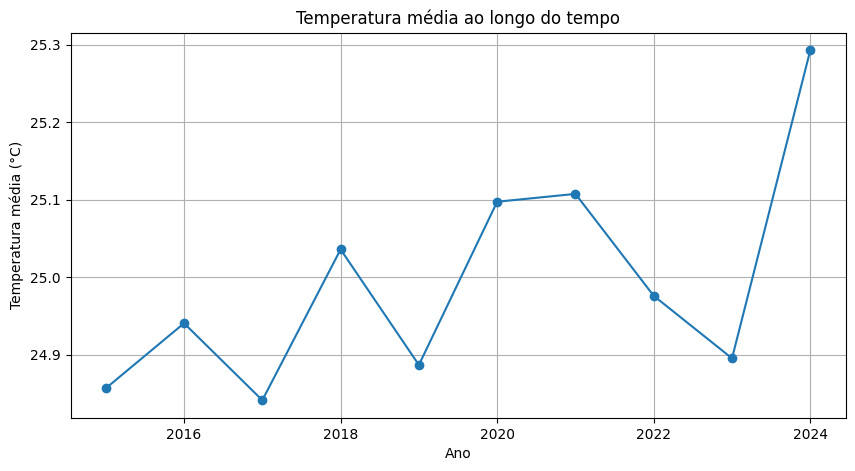

In [41]:
import matplotlib.pyplot as plt

temperatura_ano = df.groupby("ano")["temperatura_media"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    temperatura_ano.index,
    temperatura_ano.values,
    marker="o"
)

plt.title("Temperatura média ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Temperatura média (°C)")

plt.grid(True)
plt.show()

### **Chuva total ao longo do tempo**

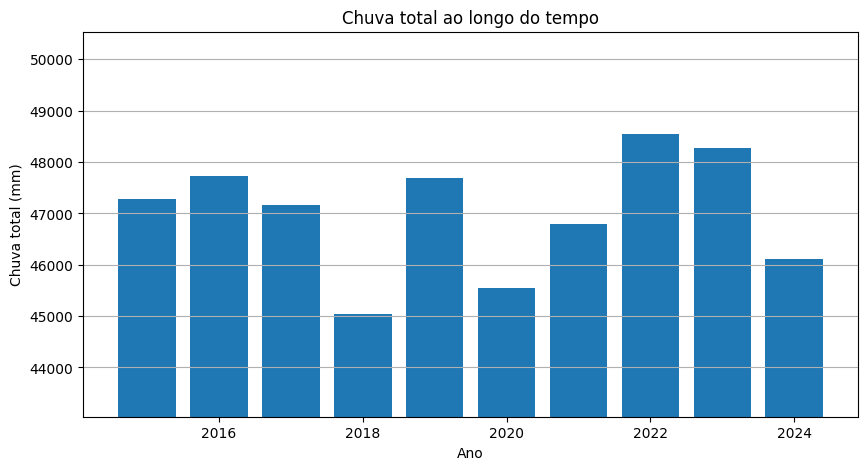

In [42]:
chuva_ano = df.groupby("ano")["chuva_mm"].sum()

plt.figure(figsize=(10, 5))

plt.bar(
    chuva_ano.index,
    chuva_ano.values
)

plt.title("Chuva total ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Chuva total (mm)")

plt.ylim(
    chuva_ano.min() - 2000,
    chuva_ano.max() + 2000
)

plt.grid(axis="y")
plt.show()

### **Volume de chuva por estado**

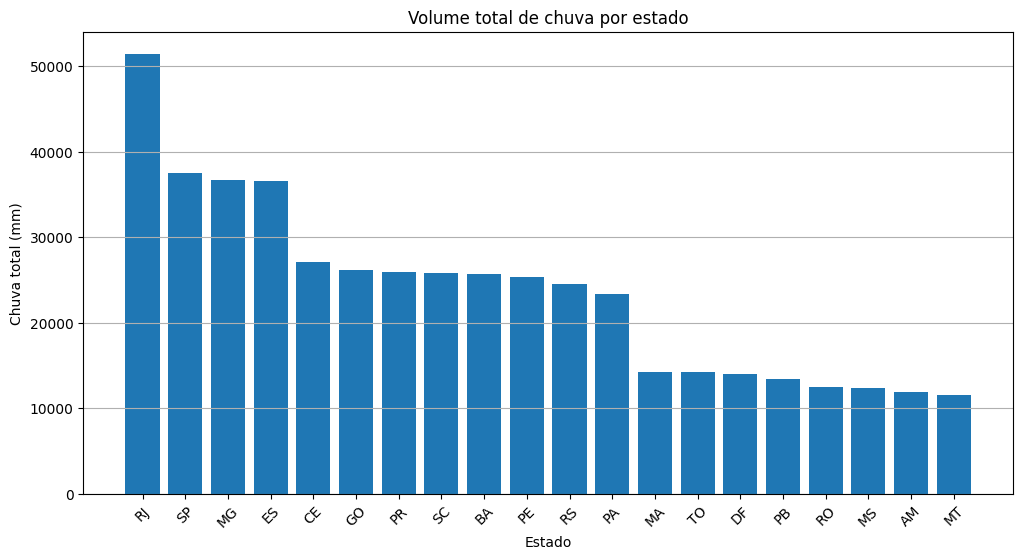

In [43]:
chuva_estado = (
    df.groupby("uf")["chuva_mm"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    chuva_estado.index,
    chuva_estado.values
)

plt.title("Volume total de chuva por estado")
plt.xlabel("Estado")
plt.ylabel("Chuva total (mm)")

plt.xticks(rotation=45)

plt.grid(axis="y")
plt.show()

### **Temperatura média por região**

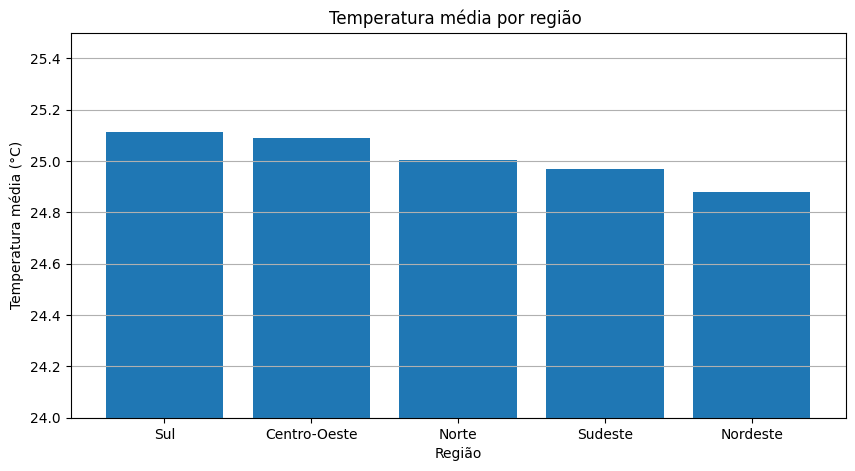

In [44]:
temperatura_regiao = (
    df.groupby("regiao")["temperatura_media"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    temperatura_regiao.index,
    temperatura_regiao.values
)

plt.title("Temperatura média por região ")
plt.xlabel("Região")
plt.ylabel("Temperatura média (°C)")

plt.ylim(24, 25.5)

plt.grid(axis="y")
plt.show()

### **Eventos extremos ao longo do tempo**

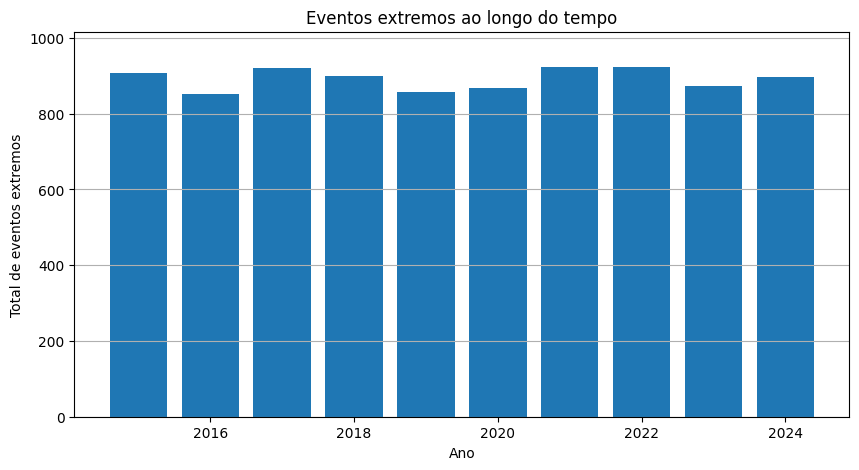

In [45]:
eventos_ano = df.groupby("ano")["eventos_extremos"].sum()

plt.figure(figsize=(10, 5))

plt.bar(
    eventos_ano.index,
    eventos_ano.values
)

plt.title("Eventos extremos ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Total de eventos extremos")

plt.ylim(
    0,
    eventos_ano.max() * 1.1
)

plt.grid(axis="y")
plt.show()

### **Temperatura média por mês e ano**

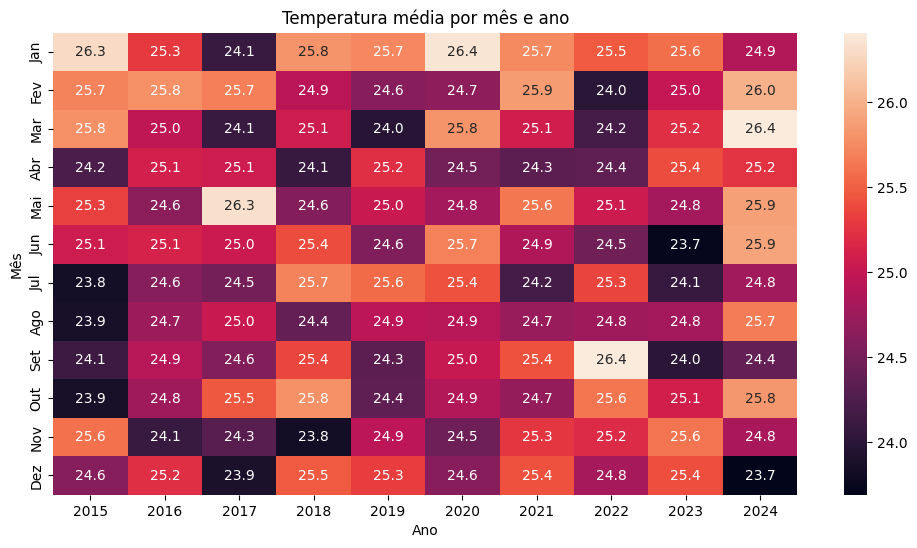

In [46]:
import seaborn as sns

meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

temperatura_mensal = df.pivot_table(
    values="temperatura_media",
    index="mes_numero",
    columns="ano",
    aggfunc="mean"
)

temperatura_mensal.index = meses

plt.figure(figsize=(12, 6))

sns.heatmap(
    temperatura_mensal,
    annot=True,
    fmt=".1f"
)

plt.title("Temperatura média por mês e ano")
plt.xlabel("Ano")
plt.ylabel("Mês")

plt.show()

### **Temperatura média x chuva**

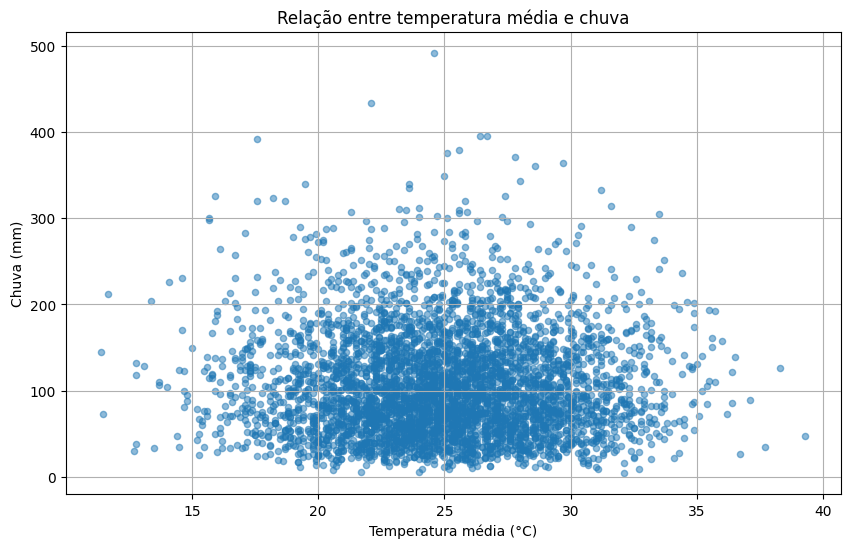

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["temperatura_media"],
    df["chuva_mm"],
    alpha=0.5,
    s=20
)

plt.title("Relação entre temperatura média e chuva")
plt.xlabel("Temperatura média (°C)")
plt.ylabel("Chuva (mm)")

plt.grid(True)
plt.show()

In [48]:
correlacao_temperatura_chuva = (
    df["temperatura_media"].corr(df["chuva_mm"])
)

print(
    f"Correlação entre temperatura média e chuva: "
    f"{correlacao_temperatura_chuva:.2f}"
)

Correlação entre temperatura média e chuva: -0.01


## **9. Interpretação**



Os resultados obtidos permitem observar diferentes características dos dados climáticos analisados entre 2015 e 2024.

A temperatura média apresentou variações ao longo dos anos, com o maior valor médio registrado em 2024, de aproximadamente 25,29 °C. Na comparação entre as regiões, o Sul apresentou a maior temperatura média, seguido pelo Centro-Oeste, Norte, Sudeste e Nordeste. As diferenças entre as regiões foram pequenas.

Em relação às chuvas, 2022 apresentou o maior volume total anual, com 48.538,5 mm, enquanto 2018 apresentou o menor volume, com 45.040,3 mm. Na comparação entre os estados, o Rio de Janeiro apresentou o maior volume total de chuva na base analisada.

A ocorrência de eventos extremos também apresentou variações entre os anos. O maior total foi registrado em 2021, com 924 eventos, seguido por 2022, com 923 eventos. No período analisado, foram contabilizados 8.918 eventos extremos.

A análise mensal mostrou variações sazonais nas temperaturas. Janeiro apresentou a maior temperatura média mensal, com aproximadamente 25,53 °C, enquanto abril apresentou a menor, com aproximadamente 24,75 °C.

Por fim, o gráfico de dispersão entre temperatura média e chuva mostra uma grande concentração de registros em diferentes níveis de chuva e temperatura. A correlação calculada entre as duas variáveis foi de -0,01, indicando que, nesta base, não foi observada uma relação linear relevante entre temperatura média e volume de chuva.

## **10. Conclusão**



A análise dos dados climáticos do Brasil entre 2015 e 2024 permitiu identificar variações de temperatura, chuva, eventos extremos e padrões sazonais.

Entre os principais resultados, 2024 apresentou a maior temperatura média anual, enquanto 2022 apresentou o maior volume total de chuva. O Rio de Janeiro apresentou o maior volume total de chuva entre os estados, e 2021 registrou o maior número de eventos extremos.

A análise também mostrou diferenças pequenas entre as temperaturas médias das regiões e uma correlação de -0,01 entre temperatura média e chuva, indicando ausência de uma relação linear relevante entre essas duas variáveis na base analisada.

Por se tratar de uma base de dados simulada, os resultados representam os padrões presentes no conjunto analisado e não devem ser interpretados como medições reais do clima brasileiro.